<a href="https://colab.research.google.com/github/eeeewyz/Audio-course/blob/main/3_audio_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from datasets import load_dataset

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")

README.md:   0%|          | 0.00/23.5k [00:00<?, ?B/s]

en-AU/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 37.3MB            

en-AU/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/654 [00:00<?, ? examples/s]

In [4]:
from datasets import Audio
#用数据集的 cast_column 方法：在加载时实时进行重采样处理。

minds = minds.cast_column("audio", Audio(sampling_rate=16_000))

In [5]:
# 使用英文括号获取数据集长度
print(len(minds))

654


In [6]:
print(minds[0])

{'path': 'en-AU~PAY_BILL/response_4.wav', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7b72d36fd160>, 'transcription': 'I would like to pay my electricity bill using my card can you please assist', 'english_transcription': 'I would like to pay my electricity bill using my card can you please assist', 'intent_class': 13, 'lang_id': 2}


In [7]:
#看某条数据的sampling_rate
print(minds[0]['audio']['sampling_rate'])

16000


In [8]:
# 获取数据集的整体音频采样率，因为已经通过 cast_column 统一设置
print(minds.features['audio'].sampling_rate)


16000


In [9]:
# 查看第一条数据的 array 部分
print(minds[0]['audio']['array'])


[0.         0.00012415 0.00024414 ... 0.00071331 0.0012207  0.00144803]


In [10]:
#因为我们要过滤太长的音频，所以我们先定义一个函数，符合的话返回true

MAX_DURATION_IN_SECONDS = 20.0


def is_audio_length_in_range(input_length):
    return input_length < MAX_DURATION_IN_SECONDS

In [11]:
import librosa

# ========================================
# 1. 计算每条音频的时长 duration
# ========================================

# librosa.get_duration() 根据音频采样点数量 + sampling_rate 计算音频的持续时间
new_column = [
    librosa.get_duration(
        y=x["array"],
        sr=x["sampling_rate"]
    )
    for x in minds["audio"]
]

# 把刚刚计算出的音频时长添加到数据集中，新增一列 "duration"
minds = minds.add_column("duration", new_column)

# 打印第一条数据的时长以验证
print(f"第一条数据的时长为: {minds[0]['duration']} 秒")

第一条数据的时长为: 7.801875 秒


In [12]:
# 使用数据集的 `filter` 方法应用过滤函数，筛选出时长符合要求的音频
minds = minds.filter(is_audio_length_in_range, input_columns=["duration"])

# 过河拆桥：移除用于过滤的临时辅助列 "duration"
minds = minds.remove_columns(["duration"])
minds

Filter:   0%|          | 0/654 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 624
})

In [13]:
#我们可以确认，该数据集的示例数量已经从 654 个减少到了 624 个。


In [2]:
#建立一个对于自定义数据来说，可能需要更复杂的预处理操作。在这种情况下，你可以扩展函数 prepare_dataset 来实现任何所需的自定义数据转换，来提取特征：可以做到framing——windowing——FFT-mel-logmel等过程

from transformers import WhisperFeatureExtractor

feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

In [14]:
#定义一个函数处理样本，对于自定义数据来说，可能需要更复杂的预处理操作，这时扩展函数 prepare_dataset 来实现任何所需的自定义数据转换
def prepare_dataset(example):
    audio = example["audio"]

    #如果sampling—_rate不是16000那么重新采样
    if audio["sampling_rate"] != 16000:
        audio_array = librosa.resample(
            audio["array"], orig_sr=audio["sampling_rate"], target_sr=16000
        )
        audio = {"array": audio_array, "sampling_rate": 16000}

    #用之前的extractor来进行单样本处理
    features = feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"], padding=True
    )
    return features

In [15]:
#对整个数据集进行处理：using Datasets’ map method:
minds = minds.map(prepare_dataset)
minds

Map:   0%|          | 0/624 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_features'],
    num_rows: 624
})

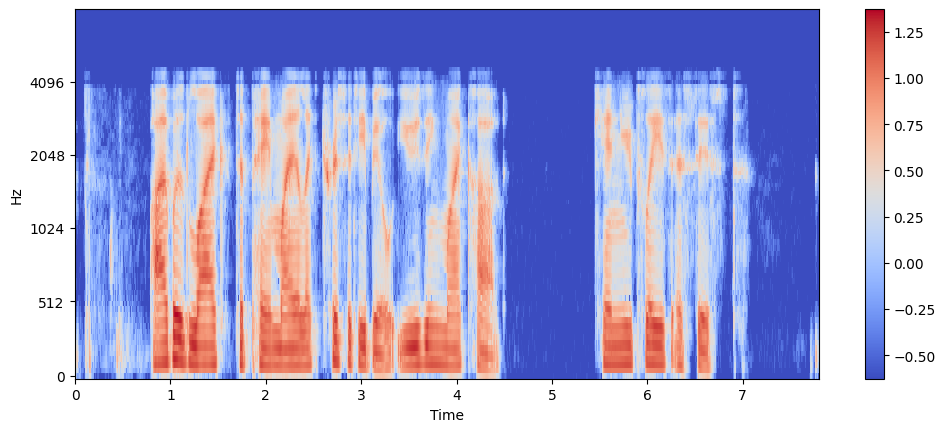

In [17]:
import numpy as np
import matplotlib.pyplot as plt

#画出 log-mel 频谱图
example = minds[0]
input_features = example["input_features"]

plt.figure().set_figwidth(12)
librosa.display.specshow(
    np.asarray(input_features[0]),
    x_axis="time",
    y_axis="mel",
    sr=feature_extractor.sampling_rate,
    hop_length=feature_extractor.hop_length,
)
plt.colorbar()